<a href="https://colab.research.google.com/github/tatyanalitvin/python_for_ds_tasks/blob/dev/Copy_of_HW_2_2_%D0%9B%D0%BE%D0%B3%D1%96%D1%81%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%8F_%D0%B7_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --upgrade --quiet
!pip install pyarrow --quiet

In [2]:
import os
from google.colab import userdata
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [3]:
# Якщо помилка, то просто перезапустити повторно імпорти, не завжди дані користовача встигають записатись
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    RobustScaler,
    StandardScaler
    )
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,

    )
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import f1_score

from sklearn.metrics import RocCurveDisplay, roc_auc_score

import joblib

from imblearn.over_sampling import SMOTE

import opendatasets as od
from kaggle.api.kaggle_api_extended import KaggleApi

In [4]:
api = KaggleApi()
api.set_config_value('username', userdata.get('KAGGLE_USERNAME'), quiet=True)
api.set_config_value('key', userdata.get('KAGGLE_API_TOKEN'), quiet=True)

competition = 'bank-customer-churn-prediction-dlu-course-c-4'
# api.competition_download_files(competition, path='.', quiet=False)

В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [5]:
files = api.competition_list_files(competition)
for file in files.files:
    print(file.name)

sample_submission.csv
test.csv
train.csv


In [6]:
def load_competition_data(competition):
    files = api.competition_list_files(competition).files
    return {
        f.name[:-4]: (
            api.competition_download_file(competition, f.name, path='.'),
            pd.read_csv(f.name)
        )[1]
        for f in files if f.name.endswith('.csv')
    }

dfs = load_competition_data(competition)

raw_train_df = dfs['train'].set_index('id')
raw_test_df = dfs['test'].set_index('id')
raw_sample_submission = dfs['sample_submission']

sample_submission.csv: Skipping, found more recently modified local copy (use --force to force download)
test.csv: Skipping, found more recently modified local copy (use --force to force download)
train.csv: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
raw_train_df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,15807989.0,Ch'iu,585.0,France,Male,33.0,3.0,0.00,1.0,1.0,0.0,54191.38,0.0
14996,15731781.0,Ch'ang,678.0,France,Male,34.0,6.0,0.00,2.0,1.0,1.0,53437.10,0.0
14997,15667093.0,Goliwe,678.0,France,Female,54.0,4.0,0.00,1.0,1.0,0.0,147720.29,1.0


In [8]:
raw_train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       15000 non-null  float64
 1   Surname          15000 non-null  object 
 2   CreditScore      15000 non-null  float64
 3   Geography        15000 non-null  object 
 4   Gender           15000 non-null  object 
 5   Age              15000 non-null  float64
 6   Tenure           15000 non-null  float64
 7   Balance          15000 non-null  float64
 8   NumOfProducts    15000 non-null  float64
 9   HasCrCard        15000 non-null  float64
 10  IsActiveMember   15000 non-null  float64
 11  EstimatedSalary  15000 non-null  float64
 12  Exited           15000 non-null  float64
dtypes: float64(10), object(3)
memory usage: 1.6+ MB


In [9]:
raw_train_df.describe().round(2)

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.0
mean,15691456.68,658.94,37.74,5.03,42729.79,1.59,0.79,0.49,117784.67,0.2
std,135205.03,72.26,8.22,2.78,59727.31,0.53,0.41,0.50,45734.45,0.4
min,1581102.00,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,15635143.00,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83058.14,0.0
50%,15690175.00,662.00,37.00,5.00,0.00,2.00,1.00,0.00,123584.87,0.0
75%,15757181.50,708.00,42.00,7.00,109531.02,2.00,1.00,1.00,156884.70,0.0
max,15815690.00,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48,1.0


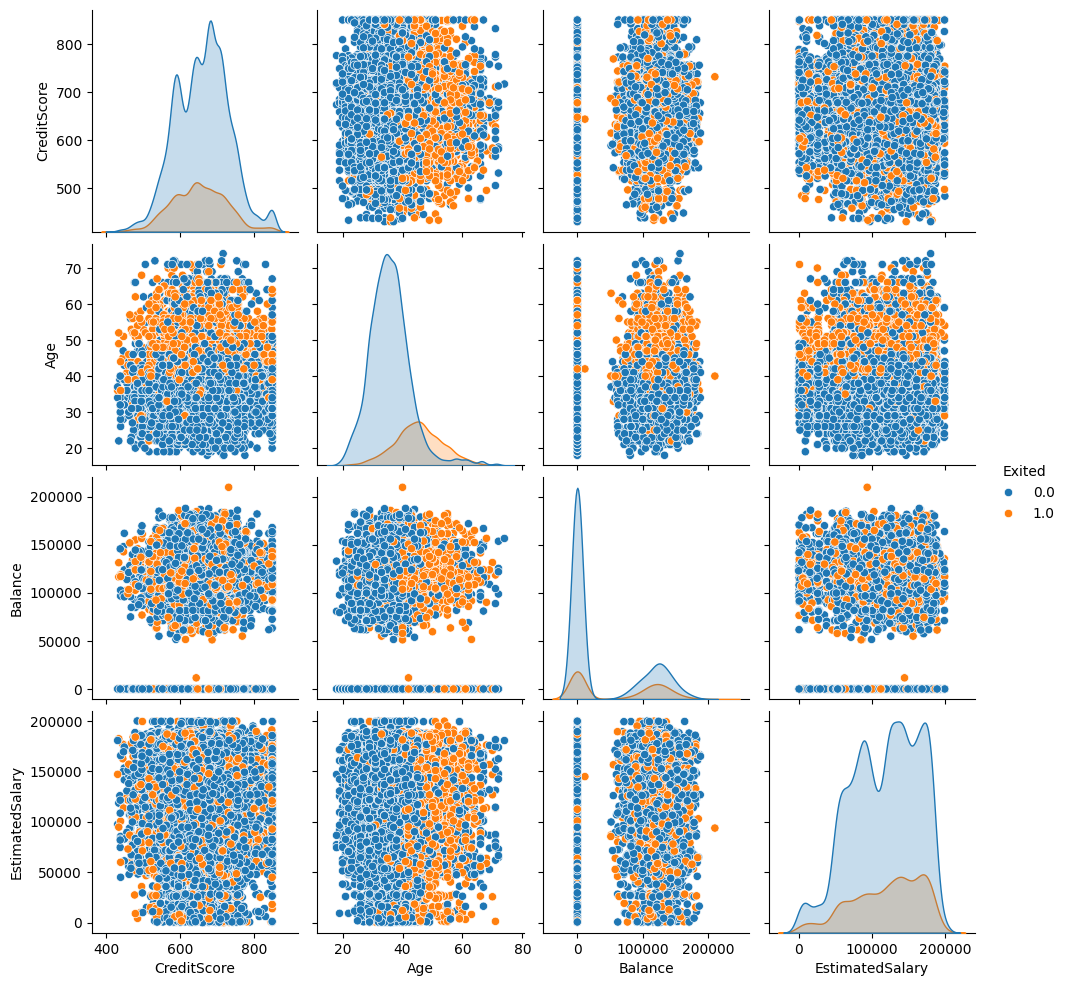

In [10]:
cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Exited']
sns.pairplot(raw_train_df[cols], hue='Exited', diag_kind='kde')
plt.show()

In [11]:
# ?train_test_split

In [12]:
train_df, val_df = train_test_split(
    raw_train_df,
    test_size=0.25,
    random_state=42,
    stratify=raw_train_df['Exited']
    )

2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [13]:
train_df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [14]:
input_cols = [
    col for col in train_df.columns
    if col not in ['CustomerId', 'Surname', 'Exited']
    ]
target_col = ['Exited']
print(f"""
input_cols: {input_cols}
target_col : {target_col}
""")

train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

val_inputs = val_df[input_cols]
val_targets = val_df[target_col]



input_cols: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
target_col : ['Exited']



3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [15]:
numeric_cols = train_inputs.select_dtypes(include='number').columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

print(f"""
numeric_cols: {list(numeric_cols)}
categorical_cols: {list(categorical_cols)}
""")


numeric_cols: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
categorical_cols: ['Geography', 'Gender']



In [16]:
train_inputs['Geography'].unique()

array(['France', 'Germany', 'Spain'], dtype=object)

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [17]:
steps = [
    ('preprocessor', ColumnTransformer([
        ('scaler', StandardScaler(), numeric_cols), # MinMaxScaler
        ('onehot', OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ])
    ),

]

pipeline = Pipeline(steps)
pipeline.set_output(transform='pandas')


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  ['CreditScore', 'Age',
                                                   'Tenure', 'Balance',
                                                   'NumOfProducts', 'HasCrCard',
                                                   'IsActiveMember',
                                                   'EstimatedSalary']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Geography', 'Gender'])]))])

1. Scaler потрібен бо у нас є фічі з різним мінімумом і максимуом, треба мати можливість їх порівнювати, а для цього перевести на одну "шкалу"
2. Обробка категоріальних змінних, щоб мати змогу їх використовувати при навчанні моделі.

In [18]:
train_inputs = pipeline.fit_transform(train_inputs, train_targets)
train_inputs.columns = (
    train_inputs.columns
      .str.replace("scaler__", "")
      .str.replace("onehot__", "")
    )

display(train_inputs.head().round(2))

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
id,,,,,,,,,,,,
8263,0.51,-0.70,-0.01,1.46,-1.11,0.51,1.02,-0.68,1.0,0.0,0.0,1.0
14199,-0.37,-0.70,-0.37,1.28,-1.11,0.51,-0.98,1.31,0.0,1.0,0.0,0.0
1856,0.28,-1.93,-0.37,-0.72,0.77,0.51,1.02,0.98,1.0,0.0,0.0,0.0
3013,0.64,1.27,-0.73,-0.72,0.77,0.51,-0.98,0.04,1.0,0.0,0.0,1.0
8266,0.51,-0.33,0.71,-0.72,0.77,0.51,-0.98,-0.38,1.0,0.0,0.0,0.0


In [19]:
val_inputs = pipeline.transform(val_inputs)
val_inputs.columns = (
    val_inputs.columns
    .str.replace("scaler__", "")
    .str.replace("onehot__", "")
    )

display(val_inputs.head().round(2))

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
id,,,,,,,,,,,,
1855,-1.61,-1.07,1.43,1.28,-1.11,-1.95,-0.98,-1.36,1.0,0.0,0.0,1.0
1273,-0.85,0.41,-0.73,1.35,-1.11,0.51,-0.98,1.29,0.0,1.0,0.0,1.0
5414,-0.53,-0.82,0.71,-0.72,-1.11,0.51,1.02,0.71,1.0,0.0,0.0,1.0
10923,-0.86,2.25,-0.73,-0.72,4.53,0.51,-0.98,-0.33,1.0,0.0,0.0,1.0
5835,1.25,0.53,-0.01,-0.72,-1.11,0.51,1.02,1.40,0.0,0.0,1.0,0.0


In [20]:
processed_input_cols = val_inputs.columns
processed_input_cols

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Geography_France',
       'Geography_Germany', 'Geography_Spain', 'Gender_Male'],
      dtype='object')

5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [21]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Colab Notebooks/ML for People/HW_2_2/'

train_inputs.to_parquet(f'{path}train_inputs.parquet')
train_targets.to_parquet(f'{path}train_targets.parquet')

val_inputs.to_parquet(f'{path}val_inputs.parquet')
val_targets.to_parquet(f'{path}val_targets.parquet')

print('\nList of Saved Files')
print(os.listdir(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

List of Saved Files
['train_inputs.parquet', 'train_targets.parquet', 'val_inputs.parquet', 'val_targets.parquet']


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [22]:
X_train = pd.read_parquet('train_inputs.parquet')
y_train = pd.read_parquet('train_targets.parquet')

X_val = pd.read_parquet('val_inputs.parquet')
y_val = pd.read_parquet('val_targets.parquet')

model = LogisticRegression(random_state=42, class_weight='balanced')
model.fit(X_train, train_targets)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(class_weight='balanced', random_state=42)

In [23]:
coef_names = model.feature_names_in_
coefficients = model.coef_.flatten()

coefs_df = pd.DataFrame(coefficients, columns=['Coefficient'], index=coef_names)
coefs_df.sort_values(by='Coefficient', ascending=False).style.background_gradient()


,Coefficient
Age,1.360668
Geography_Germany,1.062049
EstimatedSalary,0.040743
Tenure,-0.022138
HasCrCard,-0.070467
CreditScore,-0.144786
Balance,-0.240340
Geography_France,-0.480453
IsActiveMember,-0.543655
Geography_Spain,-0.570527


7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

==================================================  Training Results  ==================================================


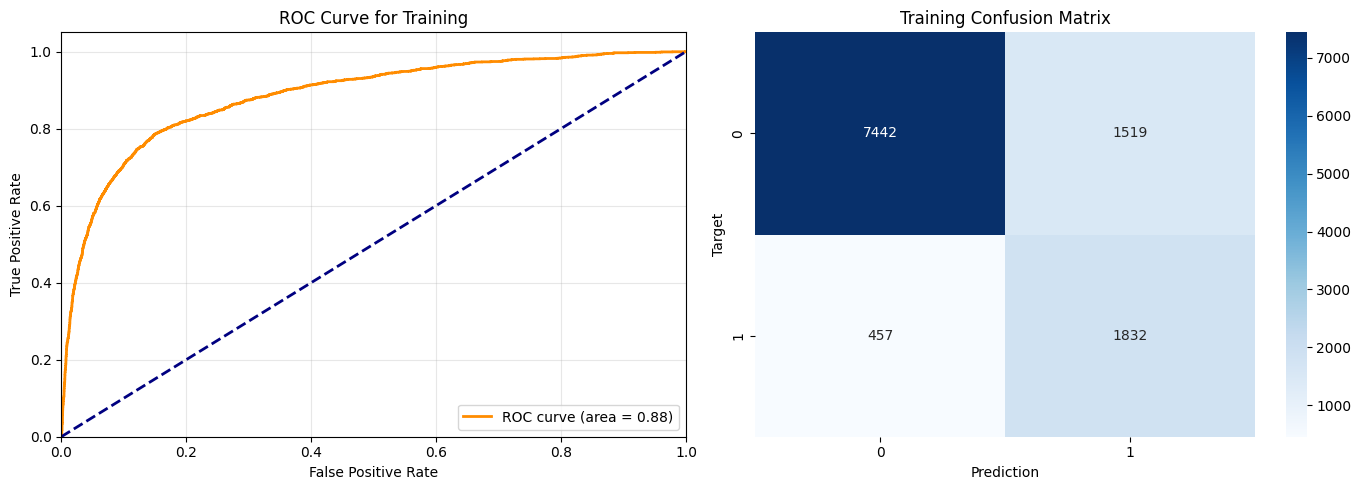


    Training Accuracy: 82.44%
    Training F1 Score: 0.6496
    Training AUROC:    0.8842
    


=================================================  Validation Results  =================================================


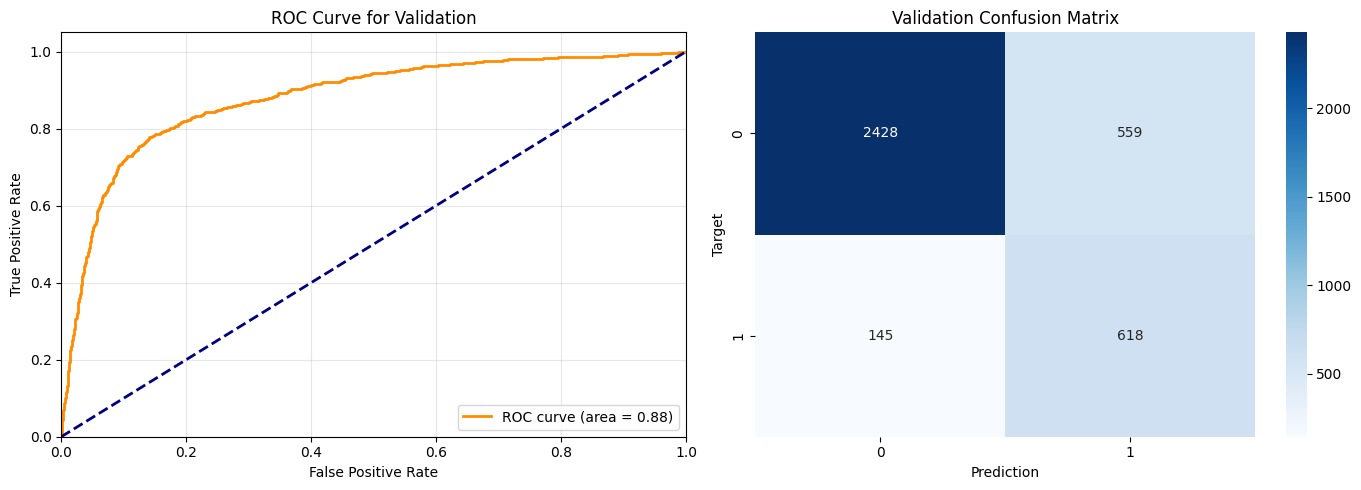


    Validation Accuracy: 81.23%
    Validation F1 Score: 0.6371
    Validation AUROC:    0.8801
    




In [24]:
def predict_and_plot(model, inputs, targets, name=''):
    y_pred = model.predict(inputs)
    y_pred_proba = model.predict_proba(inputs)[:, 1]

    # ROC крива
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Метрики
    roc_auc = auc(fpr, tpr)
    f1 = f1_score(targets, y_pred)
    accuracy = accuracy_score(targets, y_pred)
    cm = confusion_matrix(targets, y_pred)

    print(f'  {name} Results  '.center(120, '='))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC зліва
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'ROC Curve for {name}')
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)

    # Сonfusion matrix зправа
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=True)
    axes[1].set_xlabel('Prediction')
    axes[1].set_ylabel('Target')
    axes[1].set_title(f'{name} Confusion Matrix')

    plt.tight_layout()
    plt.show()

    print(f"""
    {name} Accuracy: {accuracy * 100:.2f}%
    {name} F1 Score: {f1:.4f}
    {name} AUROC:    {roc_auc:.4f}
    \n\n""")

    return y_pred

# Usage
train_preds = predict_and_plot(model, X_train, train_targets, 'Training')
val_preds = predict_and_plot(model, X_val, val_targets, 'Validation')

Виглядає, ніби модель занадто проста і може бути покращена.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [25]:
train_targets['Exited'].value_counts()

,count
Exited,
0.0,8961
1.0,2289


In [26]:
majority_class = train_targets['Exited'].mode()[0]
majority_class

np.float64(0.0)

In [27]:
dummy_preds_train = np.full(shape = len(train_targets), fill_value = majority_class)
dummy_preds_val = np.full(shape = len(val_targets), fill_value = majority_class)

dummy_accuracy_train = accuracy_score(train_targets, dummy_preds_train)
dummy_accuracy_val = accuracy_score(val_targets, dummy_preds_val)

model_acc_train = accuracy_score(train_targets, model.predict(X_train))
model_acc_val = accuracy_score(val_targets, model.predict(X_val))

print(f"""
Training   dummy model accuracy: {dummy_accuracy_train:.2%}
Validation dummy model accuracy: {dummy_accuracy_val:.2%}

Training   Logistic Regression model accuracy: {model_acc_train:.2%}
Validation Logistic Regression model accuracy: {model_acc_val:.2%}

Висновок:
""")

if model_acc_val > dummy_accuracy_val:
    print("Logistic Regression впоралась краще за dummy model яка завжди показує в якості результату мажоритарний клас. ")
elif model_acc_val == dummy_accuracy_val:
    print("Logistic Regression впоралась так само як і dummy model яка завжди показує в якості результату мажоритарний клас.")
else:
    print("Logistic Regression впоралась гірше за dummy model яка завжди показує в якості результату мажоритарний клас.")


Training   dummy model accuracy: 79.65%
Validation dummy model accuracy: 79.65%
      
Training   Logistic Regression model accuracy: 82.44%
Validation Logistic Regression model accuracy: 81.23%

Висновок:

Logistic Regression впоралась краще за dummy model яка завжди показує в якості результату мажоритарний клас. 


Насправді різниця в декілька відсотків зовсім невелика, тобто модель помиляється на мінорному класі і є запростою та не збалансованою -> може і має бути покращена

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [28]:
data_to_save = {
    'pipeline': pipeline, # Натренований preprocessor
    'model': model,       # Сама модель
    'input_cols_original': input_cols, # Назви до того, як препроцессор наставив префіксів
    'input_cols_original': processed_input_cols, # оброблені та почищені імена
    'target_col': target_col,  # таргет
    'X_train_df': X_train,
    'y_train_df': y_train,
    'X_val_df': X_val,
    'y_val_df': y_val
}

joblib.dump(data_to_save, 'log_reg.joblib')

['log_reg.joblib']

In [29]:
loaded_data = joblib.load('log_reg.joblib')
model_2 = loaded_data['model']
model_2

LogisticRegression(class_weight='balanced', random_state=42)

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [30]:
import warnings
warnings.filterwarnings("ignore")

In [31]:
def predict_raw_df(
    pipeline,
    model,
    input_df: pd.DataFrame
    ):
    X_input = pipeline.transform(input_df)
    X_input.columns = (
        X_input.columns
        .str.replace("scaler__", "")
        .str.replace("onehot__", "")
    )

    prob = model.predict_proba(X_input)[:, 1]
    return prob

predict_raw_df(pipeline, model_2, val_df)

array([0.15789026, 0.849277  , 0.10182953, ..., 0.12267553, 0.54925608,
       0.42667809])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [32]:
# Uploaded in step 1, just renaming to match the task
test_raw_df = raw_test_df

In [33]:
test_preds = predict_raw_df(pipeline, model_2, test_raw_df)
test_preds

array([0.21984718, 0.1330153 , 0.40761635, ..., 0.0559095 , 0.38649427,
       0.20703206])

12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [34]:
submission = raw_sample_submission
submission['Exited'] = test_preds
submission.head()


,id,Exited
0,15000,0.219847
1,15001,0.133015
2,15002,0.407616
3,15003,0.481578
4,15004,0.208463


In [35]:
submission.to_csv('submission_log_reg.csv', index=False)